# Estimating pi with random points

Here is the idea: scatter 10,000 random points across the square $[-1, 1] \times [-1, 1]$ and count how many land inside the unit circle. Since the circle takes up $\pi / 4$ of the square, multiplying that fraction by four gives us an estimate of $\pi$.

In [1]:
%matplotlib inline

import math
import random

from matplotlib import pyplot as plt

SEED = 42
NUM_POINTS = 10_000
rng = random.Random(SEED)

points = [
    (rng.uniform(-1, 1), rng.uniform(-1, 1))
    for _ in range(NUM_POINTS)
]
inside_circle = [x**2 + y**2 <= 1 for x, y in points]
points_inside = sum(inside_circle)
pi_estimate = 4 * points_inside / NUM_POINTS
absolute_error = abs(pi_estimate - math.pi)

print(f"Points in the circle: {points_inside:,} / {NUM_POINTS:,}")
print(f"Our estimate of pi: {pi_estimate:.4f}")
print(f"Difference from math.pi: {absolute_error:.6f}")

Points in the circle: 7,848 / 10,000
Our estimate of pi: 3.1392
Difference from math.pi: 0.002393


Because the points are random, the estimate will not be exact. With more points it usually gets closer to $\pi$. The plot below makes the experiment visible: blue points landed inside the circle, while orange points missed it.

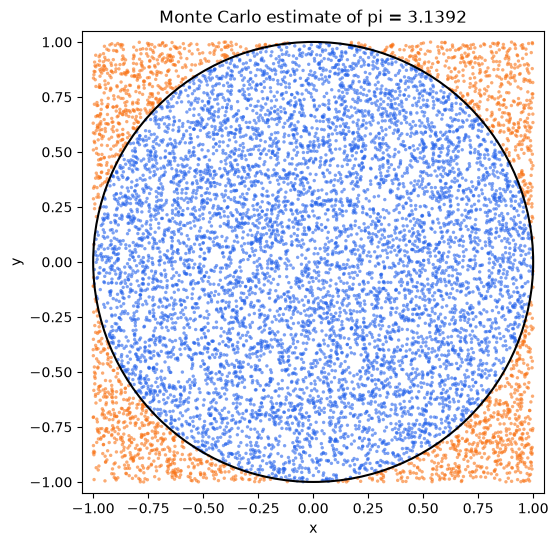

In [2]:
x_values = [x for x, _ in points]
y_values = [y for _, y in points]
colors = ["#2563eb" if is_inside else "#f97316" for is_inside in inside_circle]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_values, y_values, c=colors, s=6, alpha=0.6, linewidths=0)
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="black", linewidth=1.5))
ax.set(
    xlim=(-1.05, 1.05),
    ylim=(-1.05, 1.05),
    xlabel="x",
    ylabel="y",
    title=f"{NUM_POINTS:,} random points: pi ≈ {pi_estimate:.4f}",
)
ax.set_aspect("equal")
plt.show()